In [1]:
%cd ../

/Users/paulb/Desktop/code/research/babi


In [2]:
import os
import pandas as pd
import numpy as np
import data.constants
from data import plotting
import models.constants
from models import processing, constants
import matplotlib.pyplot as plt

import importlib
importlib.reload(data.constants)
importlib.reload(models.constants)
importlib.reload(plotting)
importlib.reload(processing)

<module 'models.processing' from '/Users/paulb/Desktop/code/research/babi/models/processing.py'>

Constraint 'min_amplitude' failures: 92044
Constraint 'plateau_slope_tolerance' failures: 122982
Constraint 'plateau_vertical_tolerance' failures: 3377
Constraint 'min_length' failures: 8640
Constraint 'max_units_from_zero' failures: 478
Constraint 'unit_max_amplitude' failures: 4825
Constraint 'mean_max_amplitude_error_percentage' failures: 33
Min unit length: 0.55 seconds.
Max unit length: 1.50 seconds.
Mean unit length: 1.12 seconds.
Total unit length: 33.34 minutes.
Extracted 1778 units for training dataset.
After pruning, 1620 units remain for training dataset.
Training dataset shape: (1296, 20, 1), Validation dataset shape: (324, 20, 1)


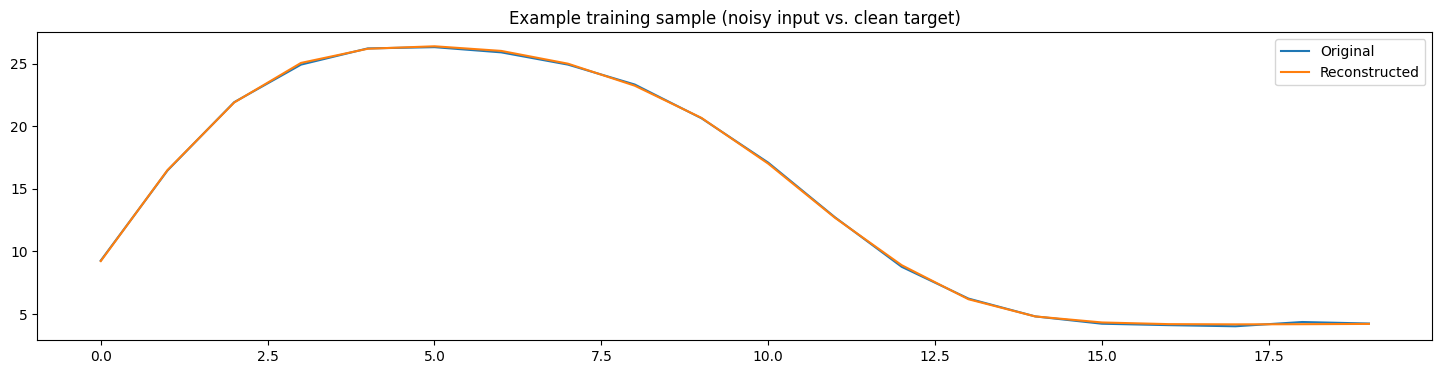

In [3]:
(train_x, train_y), val = processing.get_training_dataset(with_pruning=True)
print(f"Training dataset shape: {train_x.shape}, Validation dataset shape: {val.shape}")

plotting.dual(train_x[0], train_y[0], title="Example training sample (noisy input vs. clean target)")

In [4]:
from models import autoencoder

ae = autoencoder.build()

history = ae.fit(
    train_x, train_y,
    validation_data=(val, val),
    epochs=100,
    batch_size=32,
    shuffle=True
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 287.1316 - val_loss: 275.3775
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 191.7078 - val_loss: 130.2680
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 76.0300 - val_loss: 41.4158
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 27.9903 - val_loss: 19.4801
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 18.4107 - val_loss: 16.4626
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 17.0047 - val_loss: 16.1437
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 16.7697 - val_loss: 15.9737
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 16.6581 - val_loss: 15.8687
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 16.5924 - val_loss: 15.6666
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 16.5621 - val_loss: 15.7425
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 16.5237 - val_loss: 15.7833
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━━━

In [5]:
sample_path = os.listdir(os.path.join(data.constants.preprocessed_data_dir, "capnostream"))[1]
sample: pd.DataFrame = pd.read_pickle(os.path.join(data.constants.preprocessed_data_dir, "capnostream", sample_path))
print(sample.attrs)
signal = sample["co2_wave"].to_numpy()

{'Patient ID': 'BB_003_1', 'Patient Type': 'Infant/Neonatal', 'Report Generation Time': 'Mar 10,25  08:12:56 AM', 'Date': 'Mar 10,25'}


In [6]:
from models.processing import augmentation
from numpy.lib.stride_tricks import sliding_window_view

units = sliding_window_view(signal, (constants.unit_length, ))
units = np.array([augmentation.stretch_to_unit_length(unit)[0] for unit in units])

In [7]:
threshold = autoencoder.calculate_threshold(ae, val, percentile=95)
print(f"Calculated threshold: {threshold}")
predict = autoencoder.predictor(ae, threshold)
batch_predict = autoencoder.batch_predictor(ae, threshold)

Calculated threshold: 21.951015972494925


In [8]:
from itertools import compress

recons, errors, labels = batch_predict(units)
predictions: list[tuple[np.ndarray, np.ndarray, np.floating, np.bool]] = list(zip(units, recons, errors, labels))
valid_predictions = list(compress(predictions, labels))
invalid_predictions = list(compress(predictions, ~labels))

print(f"Total units: {len(predictions)}")
print(f"Valid units: {len(valid_predictions)} ({round(len(valid_predictions) / len(predictions) * 100, 2)}%)")
print(f"Invalid units: {len(invalid_predictions)} ({round(len(invalid_predictions) / len(predictions) * 100, 2)}%)")

Total units: 40386
Valid units: 5678 (14.06%)
Invalid units: 34708 (85.94%)



----- VALID SAMPLES -----

Valid Sample 1 (Index 5201) | 4.3 (-17.65)


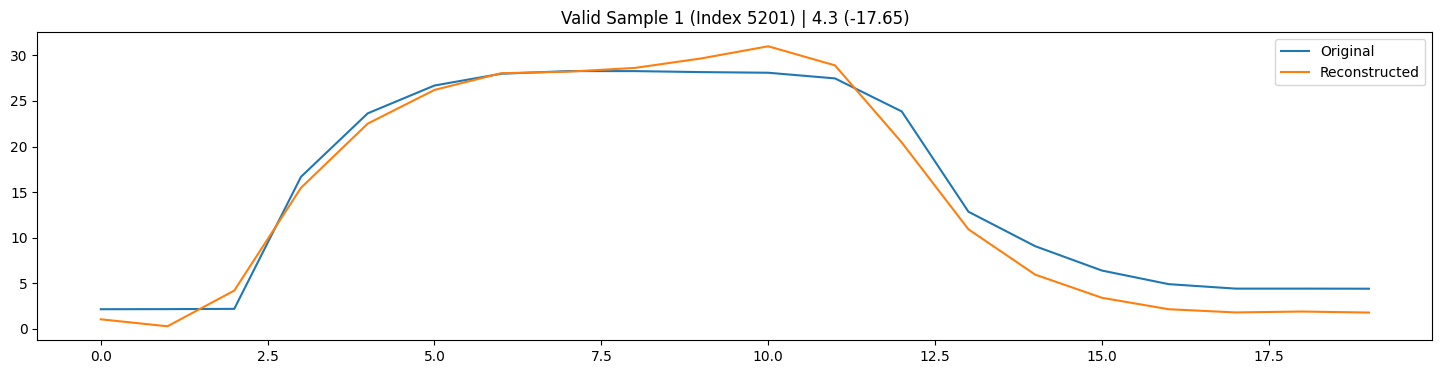

Valid Sample 2 (Index 1906) | 6.6 (-15.35)


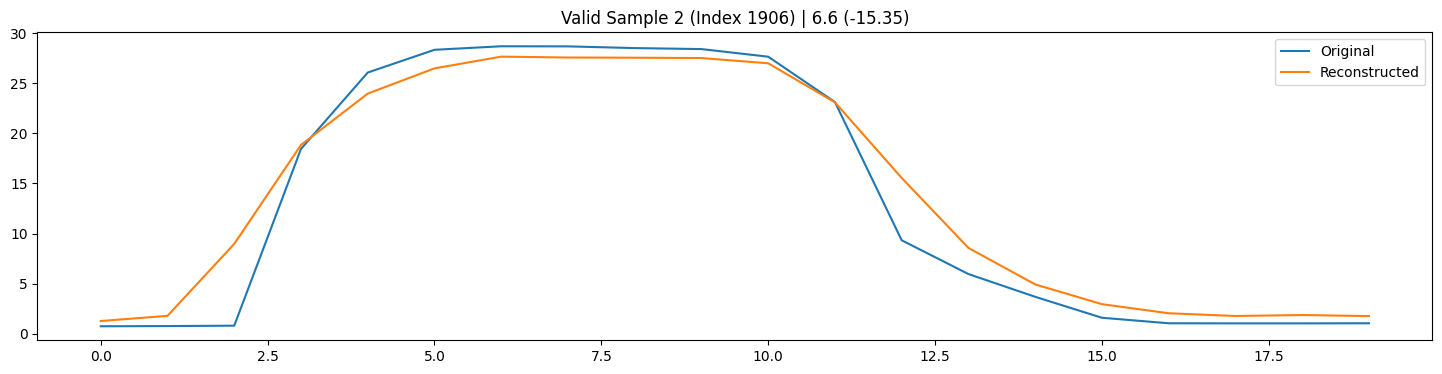

Valid Sample 3 (Index 2464) | 18.01 (-3.94)


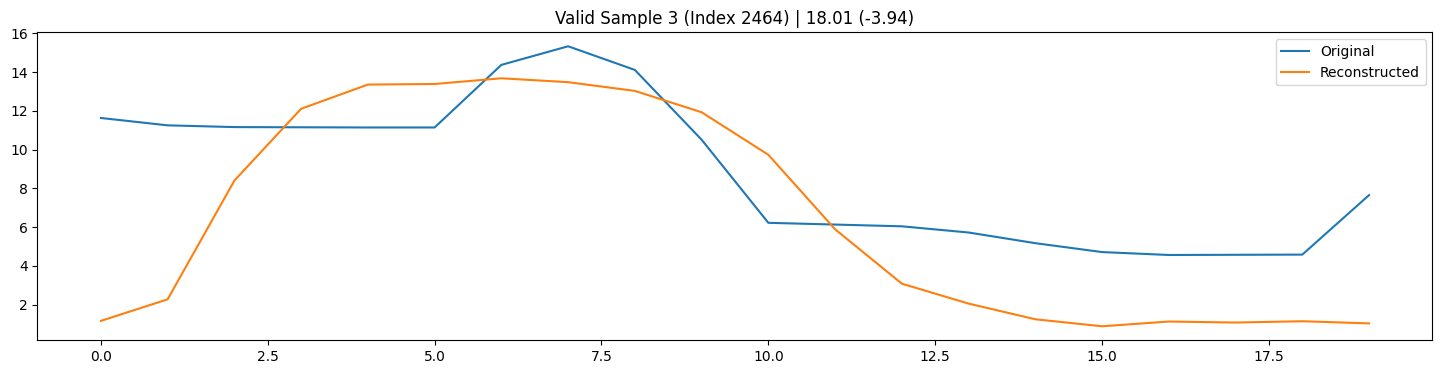


-----INVALID SAMPLES -----

Invalid Sample 1 (Index 4429) | 46.83 (24.88)


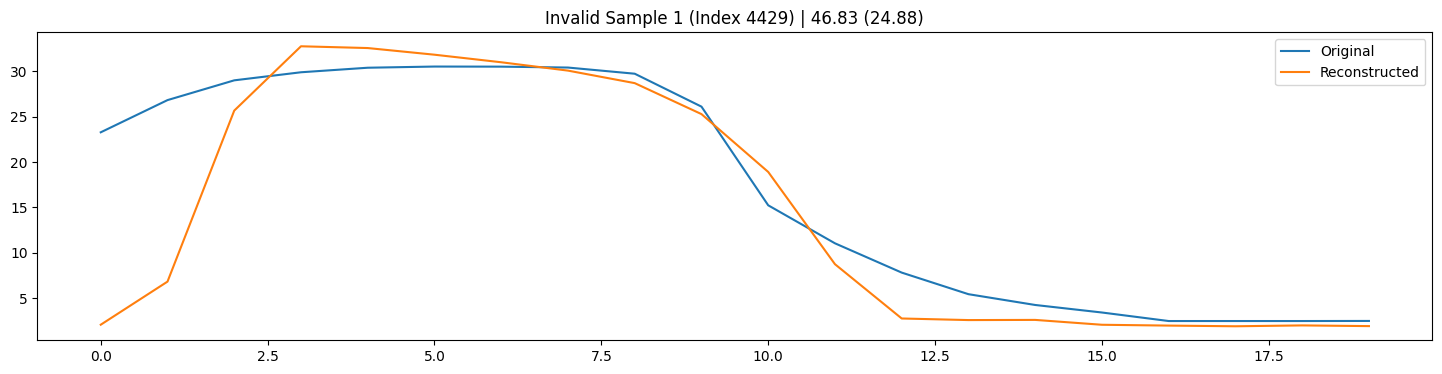

Invalid Sample 2 (Index 19455) | 103.12 (81.17)


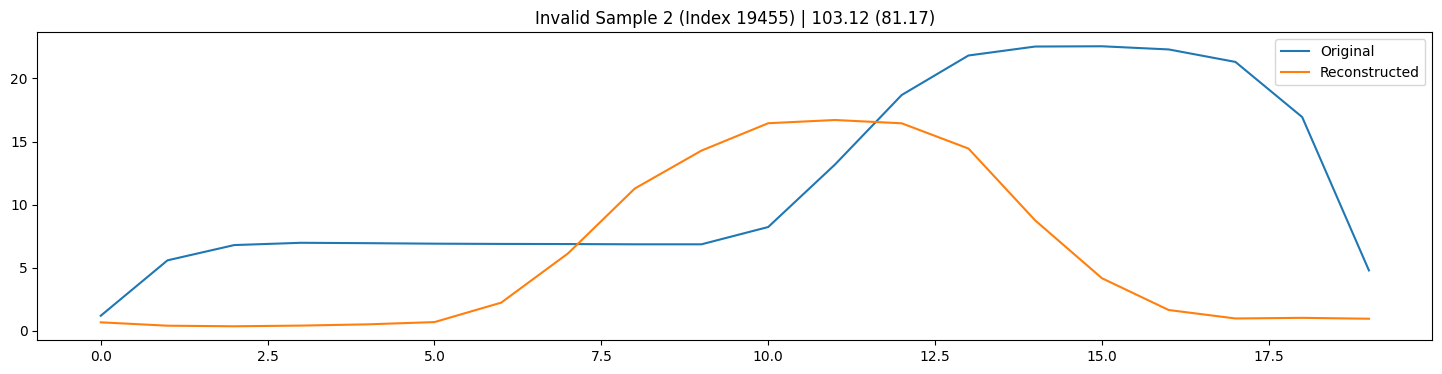

Invalid Sample 3 (Index 34686) | 393.21 (371.25)


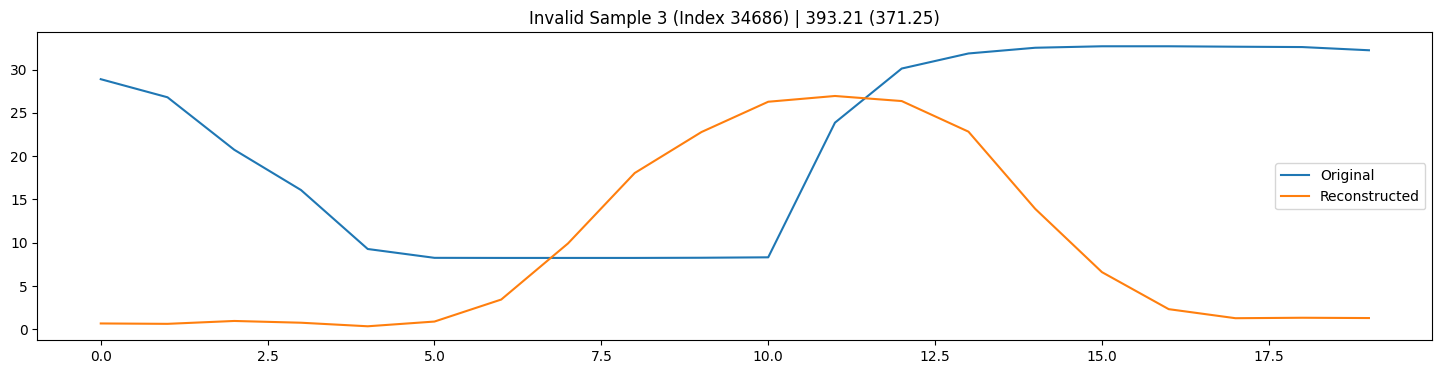

In [9]:
print("\n----- VALID SAMPLES -----\n")

n_valid_predictions = 3
for i in range(n_valid_predictions):
    index = np.random.randint(0, len(valid_predictions))
    original, recon, error, valid = valid_predictions[index]
    title = f'Valid Sample {i+1} (Index {index}) | {round(error, 2)} ({round(error - threshold, 2)})'
    print(title)
    plotting.dual(original, recon, title=title)

print("\n-----INVALID SAMPLES -----\n")

n_invalid_predictions = 3
for i in range(n_invalid_predictions):
    index = np.random.randint(0, len(invalid_predictions))
    original, recon, error, valid = invalid_predictions[index]
    title = f'Invalid Sample {i+1} (Index {index}) | {round(error, 2)} ({round(error - threshold, 2)})'
    print(title)
    plotting.dual(original, recon, title=title)

----- BEST VALID SAMPLES -----

Valid Sample 1 | 0.15 (-21.8)


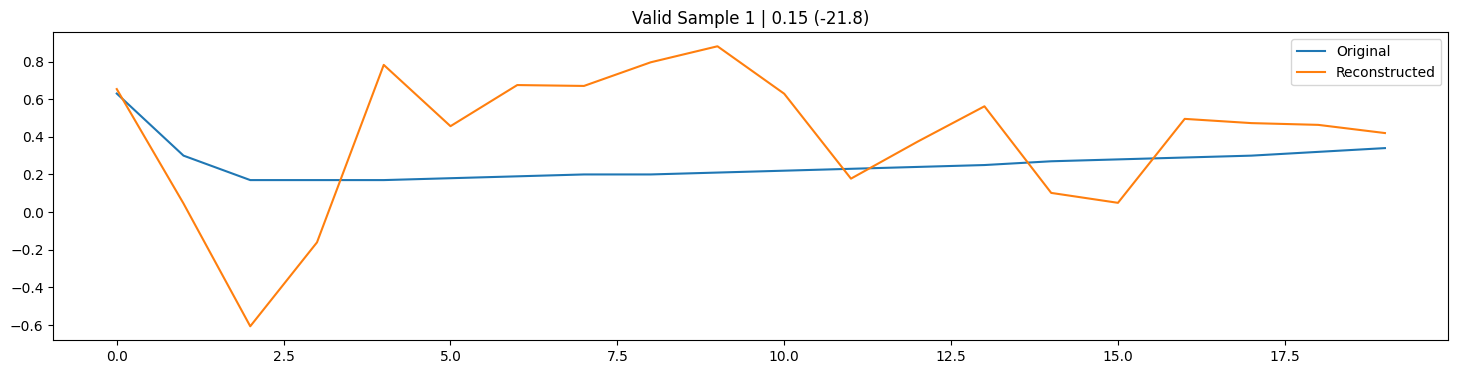

Valid Sample 2 | 0.16 (-21.79)


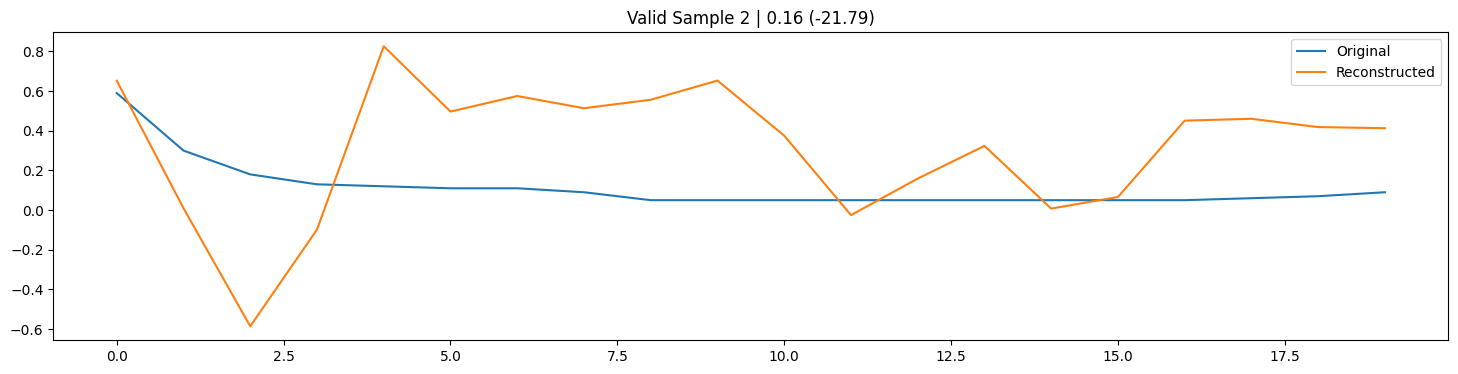

Valid Sample 3 | 0.16 (-21.79)


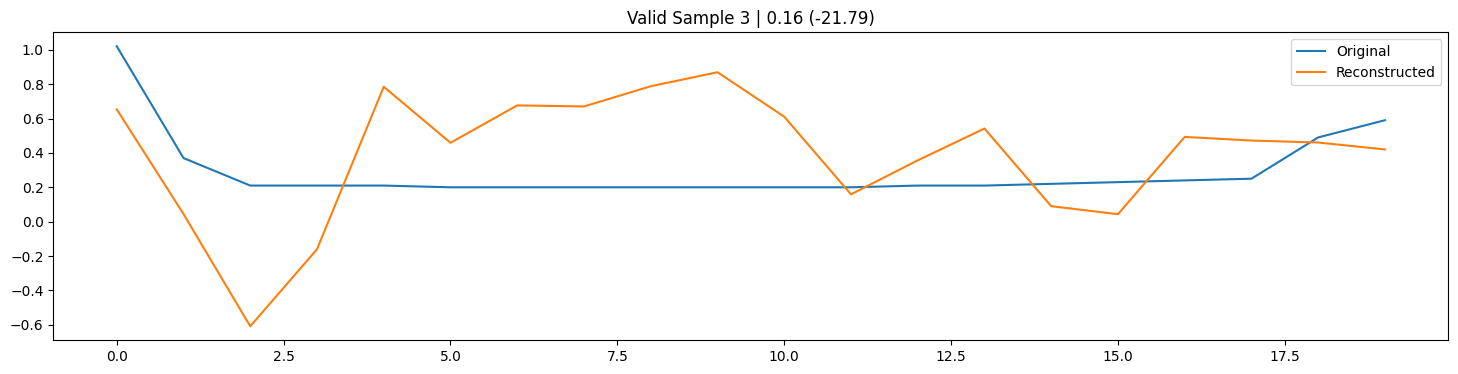


----- WORST VALID SAMPLES -----

Valid Sample 1 | 21.95 (-0.0)


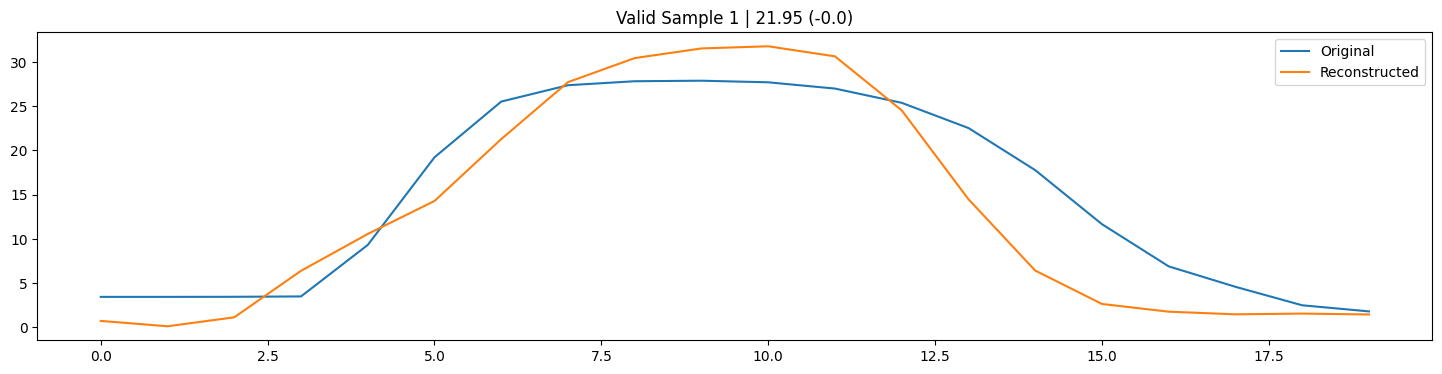

Valid Sample 2 | 21.95 (-0.0)


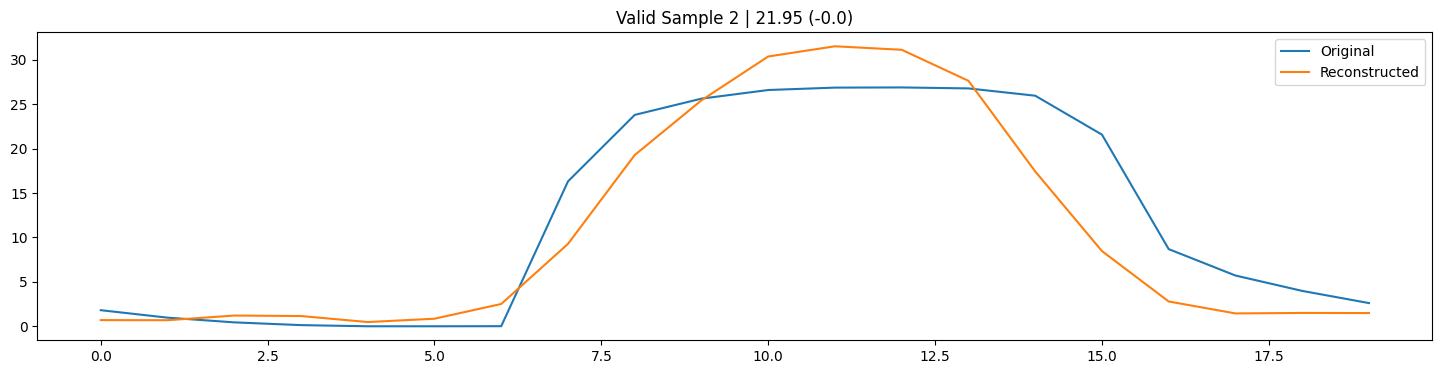

Valid Sample 3 | 21.94 (-0.01)


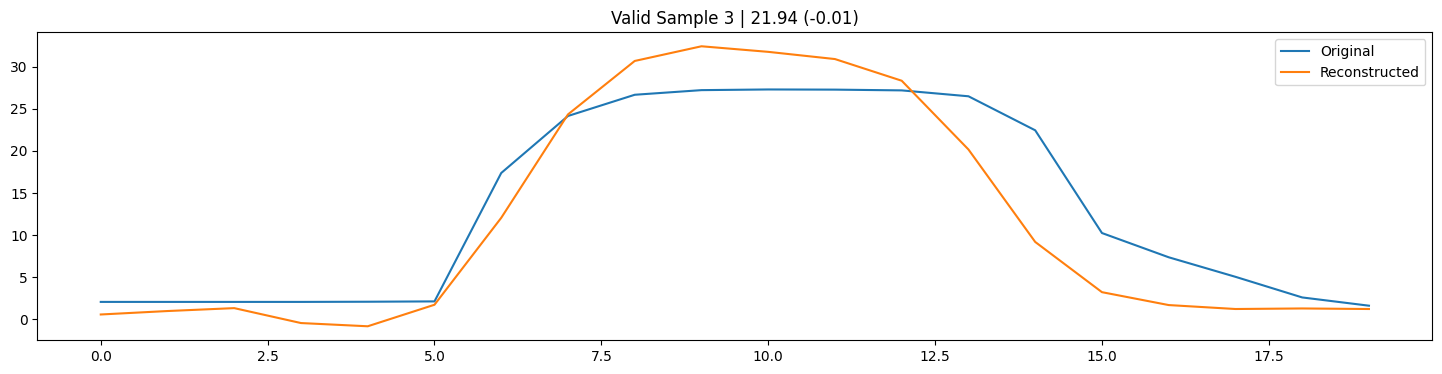

In [10]:
print("----- BEST VALID SAMPLES -----\n")

n_best_valid = 3
best_valid = sorted(valid_predictions, key=lambda x: x[2])
for i in range(n_best_valid):
    original, recon, error, valid = best_valid[i]
    title = f'Valid Sample {i+1} | {round(error, 2)} ({round(error - threshold, 2)})'
    print(title)
    plotting.dual(original, recon, title=title)

print("\n----- WORST VALID SAMPLES -----\n")

n_worst_valid = 3
worst_valid = sorted(valid_predictions, key=lambda x: x[2], reverse=True)
for i in range(n_worst_valid):
    original, recon, error, valid = worst_valid[i]
    title = f'Valid Sample {i+1} | {round(error, 2)} ({round(error - threshold, 2)})'
    print(title)
    plotting.dual(original, recon, title=title)

# todo: should penalize based on cosine similarity